In [1]:
import torch
import torchvision
from torchvision import transforms
from torchvision.transforms import Compose, Normalize, ToTensor
from ViT_CX.ViT_CX import ViT_CX
import utils.utils
from model.explainability import inference

import numpy as np
import random

from matplotlib import pyplot as plt
import cv2

import time
import pandas as pd

import rasterio as rio
import json

import gc

#root = '/home/a01328525/'
root = 'E:/Experiments/'

In [2]:
import shutil
#shutil.make_archive("/home/a01328525/transformer_object_dectection", 'zip', "/home/a01328525/transformer_object_dectection")

#shutil.make_archive("/home/a01328525/trained_models", 'zip', "/home/a01328525/Datasets_STED/runs_transformers")
#shutil.make_archive("/home/a01328525/trained_model", 'zip', "/home/a01328525/Datasets_STED/runs_transformers/STED_2_nano_cbbox_bgr_diou_BitNet")

#shutil.make_archive("/home/a01328525/results", 'zip', "/home/a01328525/Counting images paper")

#shutil.make_archive("/home/a01328525/masks20_Zone102_part1", 'zip', "/home/a01328525/Datasets_STED/Explainability/masks20_Zone102_part1")
#shutil.make_archive("/home/a01328525/masks20_Zone3", 'zip', "/home/a01328525/Datasets_STED/Explainability/masks20_Zone3")

In [3]:
def preprocess_image(img: np.ndarray) -> torch.Tensor:
    preprocessing = Compose([
        ToTensor(),
        #Normalize(mean=mean, std=std)
    ])
    return preprocessing(img.copy()).unsqueeze(0)

# Image Pre-processing function for ViT  
def img_to_tensor(img_path):
  rgb_img =plt.imread(img_path)
  rgb_img =rgb_img[...,::-1][:, :, ::-1]
  #rgb_img = cv2.imread(img_path, 1)[:, :, ::-1]
  rgb_img = cv2.resize(rgb_img, (224, 224))
  rgb_img = np.float32(rgb_img) / 255
  input_tensor = preprocess_image(rgb_img, mean=[0.5, 0.5, 0.5],std=[0.5, 0.5, 0.5])
  return input_tensor

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.06988475..1.0598137].


(224, 224, 3)
0.06988475 1.0598137


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

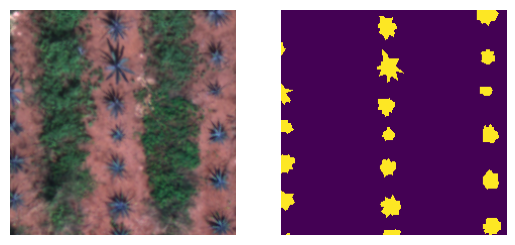

In [4]:
#root = 'E:/Experiments/'
device='cuda'
#import rasterio as rio
from tifffile import imread

#image_path = root+"/Datasets Tiles/Zone3/0182.tif" #3 plants
#image_path = root+"/Datasets Tiles/Zone3/0223.tif" #
#image_path = root+"/Datasets Tiles/Zone3/0381.tif" #
#image_path = root+"/Datasets Tiles/Zone3/0387_bgr.tif" #two plants
#image_path = root+"/Datasets Tiles/Zone3/0287.tif" #4 plants
image_path = root+"/Datasets Tiles/Zone108_octubre/5324.tif"
#image_path = root+"/Datasets Tiles/Zone3/0706.tif" #multiple plants
#image_path = root+"/Datasets Tiles/Zone102_part1/7429.tif"
        
#with rio.open(image_path) as img :
#    image = img.read()
image = imread(image_path)
gt_mask = image[...,8]
image = image[...,0:3]
print(image.shape)
print(image.min(), image.max())

zone_name='Zone3'
f = open(root+'zone_parameters.json')
zone_parameters = json.load(f)
f.close()
#correctionRGB = zone_parameters[zone_name]['correctionRGB']
#image = image/correctionRGB
#print(image.min(), image.max())

image = preprocess_image(image).to(device).requires_grad_(True)
image_plot = image[0].permute(1, 2, 0)[:,:,[2, 1, 0]].detach().cpu(); #image_plot = image_plot/image_plot.max()

plt.subplot(1, 2, 1)
plt.imshow(image_plot)
plt.axis('off')
#plt.savefig("rgb.png", dpi=300)
plt.subplot(1, 2, 2)
plt.imshow(gt_mask)
plt.axis('off')

In [5]:
folder_trained_models = root+"Datasets_STED/runs_transformers/"
#model_dir = folder_trained_models+"STED_5_nano_cbbox_bgr_diou_BitNet/best.pt"
model_dir = folder_trained_models+"explain_STED_1001_nano_cbbox_bgr_diou_BitNet/best.pt"

img_size = 224
N_channels = 3
n_model = 128
num_blks = 1
conf_thr = 0.3 #filter scores to consider only predictions with confidence score greater than conf_thr
iou_thr = 0.5#0.15# using diou #0.5
diou_thr = 0.5#0.15# using diou #0.5
obj='cbbox'
device='cuda'
bitNet = True

In [6]:
import model.transformer
model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                     obj = obj, device=device, bitNet=bitNet).to(device)

checkpoint = torch.load(model_dir, map_location=torch.device(device))
if type(checkpoint) == dict:
    model.load_state_dict(checkpoint['model'])
else:
    model.load_state_dict( checkpoint )
boxes, scores, tokens, adjusts, masks  = inference(model, image, obj, conf_thr, diou_thr, device=device)
print(tokens)

model.cpu()
del model

[tensor([[ 12],
        [ 20],
        [ 28],
        [ 32],
        [ 48],
        [ 76],
        [ 98],
        [104],
        [126],
        [132],
        [152],
        [154],
        [361],
        [476],
        [501],
        [641],
        [881],
        [950],
        [965]], device='cuda:0'), tensor([])]


In [7]:
gc.collect()
torch.cuda.empty_cache()

print(f"Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
print(f"Reserved: {torch.cuda.memory_reserved()/1024**2:.2f} MB")

Allocated: 66.50 MB
Reserved: 86.00 MB


In [8]:
import model.transformer
model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                     obj = obj, device=device, bitNet=bitNet).to(device)

checkpoint = torch.load(model_dir, map_location=torch.device(device))
if type(checkpoint) == dict:
    model.load_state_dict(checkpoint['model'])
else:
    model.load_state_dict( checkpoint )

import gc
gc.collect()
torch.cuda.empty_cache()

print(f"Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
print(f"Reserved: {torch.cuda.memory_reserved()/1024**2:.2f} MB")

Allocated: 67.95 MB
Reserved: 86.00 MB


In [9]:
arr = tokens[0].reshape(1, -1).detach().cpu().numpy().squeeze()
toks = arr.tolist() if arr.ndim > 0 else [int(arr)]
print(len(toks))
toks

19


[12,
 20,
 28,
 32,
 48,
 76,
 98,
 104,
 126,
 132,
 152,
 154,
 361,
 476,
 501,
 641,
 881,
 950,
 965]

In [11]:
np.set_printoptions(suppress=True) #supress scientific notation
# Load black box model for explanations
#model = timm.create_model('vit_base_patch16_224', pretrained=True)

import model.transformer
model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                     obj = obj, device=device, bitNet=bitNet).to(device)

checkpoint = torch.load(model_dir, map_location=torch.device(device))
if type(checkpoint) == dict:
    model.load_state_dict(checkpoint['model'])
else:
    model.load_state_dict( checkpoint )

image_cpu = image.cpu()
target_layer=model.encoder1.blks[-1].ln1
# Perform ViT-CX
n_sal, saliency_map_global = ViT_CX(model,image_cpu,target_layer,target_category=toks,distance_threshold=0.1,gpu_batch=50)
print("result ", saliency_map_global.shape)

result  torch.Size([224, 224])


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

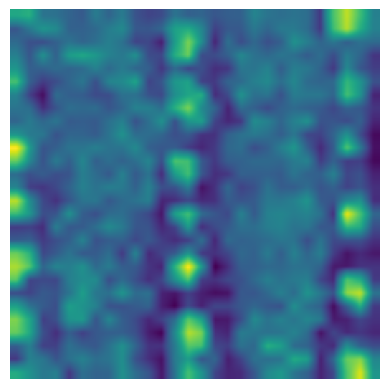

In [12]:
plt.imshow(saliency_map_global)
plt.axis('off')
#plt.savefig("explain_rgb.png", dpi=300)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

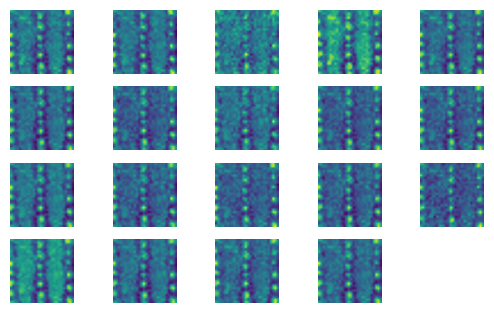

In [13]:
rows = int(np.ceil(np.sqrt(len(n_sal))))
cols = rows+1 if rows**2<len(n_sal) else rows
for i in range(n_sal.shape[0]):
    plt.subplot(rows, cols, i+1)
    plt.imshow(n_sal[i])
    plt.axis('off')

plt.imshow(saliency_map_global)
plt.axis('off')
#plt.savefig("explain_tiles_cx.png", dpi=300)

In [14]:
#model.cpu()
#del model
import gc
gc.collect()
torch.cuda.empty_cache()

print(f"Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
print(f"Reserved: {torch.cuda.memory_reserved()/1024**2:.2f} MB")

Allocated: 101.78 MB
Reserved: 172.00 MB


In [15]:
from model.explainability import deletion_auc
from model.explainability import insertion_auc
from model.explainability import pointing_game_circle
from model.explainability import topk_localization

np.float32(0.1309051)

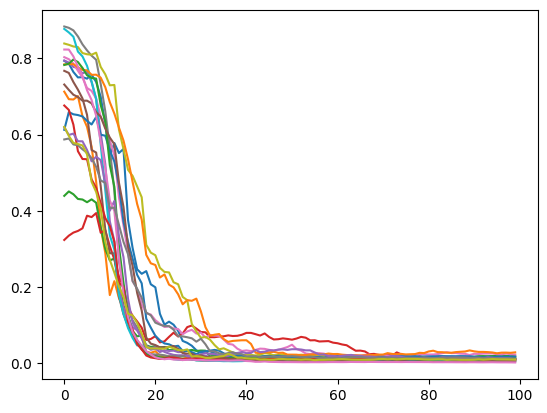

In [16]:
deletion_auc(model, image, saliency_map_global, tokens[0], boxes[0], plot=True)

np.float32(0.8685445)

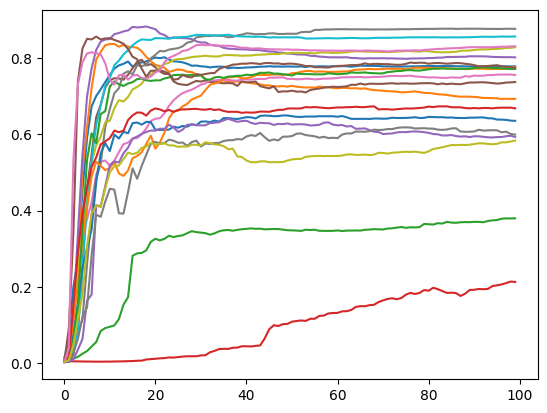

In [17]:
insertion_auc(model, image, saliency_map_global, tokens[0], boxes[0], plot=True)

In [18]:
pointing_game_circle(saliency_map_global, boxes[0], gt_mask)

np.float64(0.9473684210526315)

In [19]:
topk_localization(saliency_map_global, boxes[0], gt_mask)

np.float32(0.85614043)

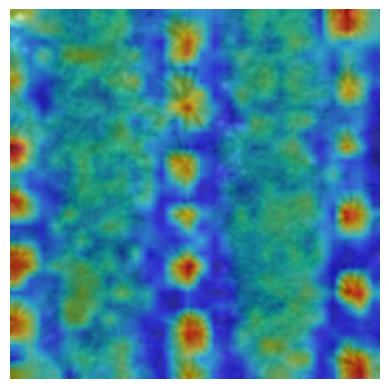

In [20]:
rgb_img2 = image_cpu[0].permute(1, 2, 0).data.cpu().numpy()
rgb_img2=(rgb_img2-rgb_img2.min())/(rgb_img2.max()-rgb_img2.min())
plt.imshow(rgb_img2)
plt.axis('off')
plt.imshow(saliency_map_global, cmap='jet', alpha=0.5)
plt.show()

In [21]:
import gc
gc.collect()
torch.cuda.empty_cache()

print(f"Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
print(f"Reserved: {torch.cuda.memory_reserved()/1024**2:.2f} MB")

Allocated: 105.15 MB
Reserved: 180.00 MB


## Visualization tile explainability

(224, 224, 3)
Allocated: 76.13 MB
Reserved: 136.00 MB
(224, 224, 3)
Allocated: 76.79 MB
Reserved: 140.00 MB
(224, 224, 3)
Allocated: 76.90 MB
Reserved: 122.00 MB
(224, 224, 3)
Allocated: 77.08 MB
Reserved: 124.00 MB
(224, 224, 3)
Allocated: 76.13 MB
Reserved: 164.00 MB
(224, 224, 3)
Allocated: 76.40 MB
Reserved: 144.00 MB
(224, 224, 3)
Allocated: 77.38 MB
Reserved: 144.00 MB
(224, 224, 3)
Allocated: 77.07 MB
Reserved: 144.00 MB
(224, 224, 3)
Allocated: 76.13 MB
Reserved: 144.00 MB


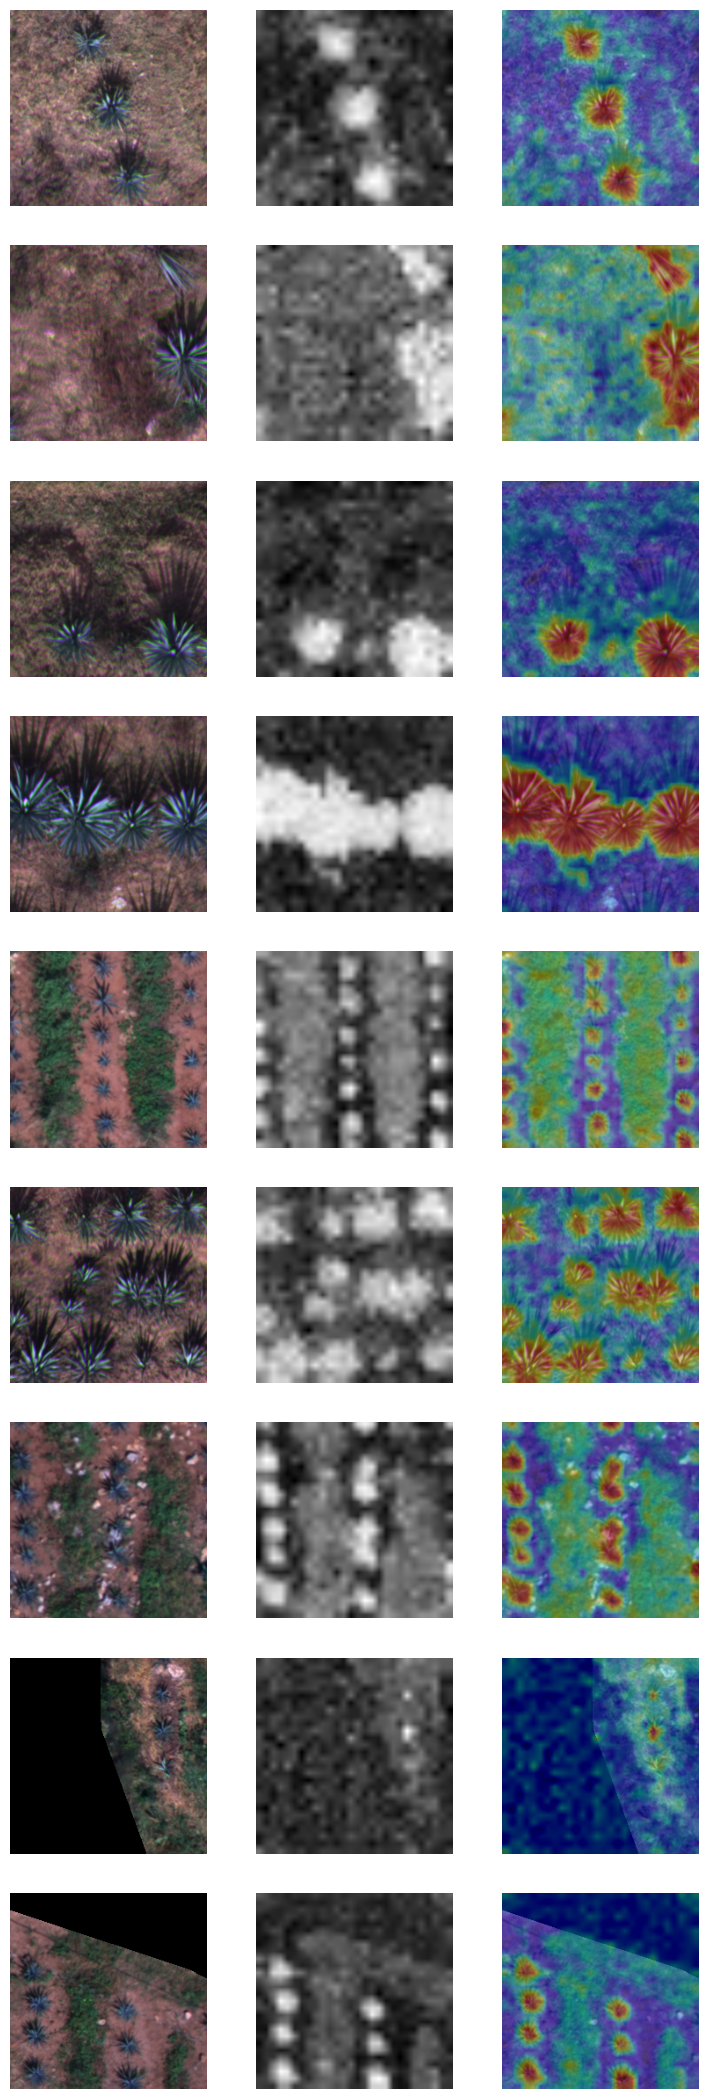

In [22]:
from explainability_generator import LRP

model_dir = folder_trained_models+"explain_STED_1001_nano_cbbox_bgr_diou_BitNet/best.pt"

image_paths = [root+"/Datasets Tiles/Zone3/0182_bgr.tif", #3 plants
                root+"/Datasets Tiles/Zone3/0223_bgr.tif",#, #
                root+"/Datasets Tiles/Zone3/0387_bgr.tif", #two plants
                root+"/Datasets Tiles/Zone3/0287_bgr.tif", #5 plants
                root+"/Datasets Tiles/Zone108_octubre/5324_bgr.tif",
                root+"/Datasets Tiles/Zone3/0706_bgr.tif", #5 plants
                root+"/Datasets Tiles/Zone108_octubre/5417_bgr.tif",
               root+"/Datasets Tiles/Zone108_octubre/5282_bgr.tif",
               root+"/Datasets Tiles/Zone108_octubre/5129_bgr.tif"
              ]
image_paths = [root+"/Datasets Tiles/Zone3/0182.tif", #3 plants
                root+"/Datasets Tiles/Zone3/0223.tif",#, #
                root+"/Datasets Tiles/Zone3/0387.tif", #two plants
                root+"/Datasets Tiles/Zone3/0287.tif", #5 plants
                root+"/Datasets Tiles/Zone108_octubre/5324.tif",
                root+"/Datasets Tiles/Zone3/0706.tif", #5 plants
                root+"/Datasets Tiles/Zone108_octubre/5417.tif",
               root+"/Datasets Tiles/Zone108_octubre/5282.tif",
               root+"/Datasets Tiles/Zone108_octubre/5129.tif"
              ]

plt.figure(figsize=(9, 3*len(image_paths)))
for i, image_path in enumerate(image_paths):
    image = imread(image_path)
    #image[...,:3] = image[...,:3]/image[...,:3].max()
    image = image[...,:3]
    print(image.shape)
    
    image = preprocess_image(image).to(device).requires_grad_(True)
    image_plot = image[0].permute(1, 2, 0)[:,:,[2, 1, 0]].detach().cpu(); image_plot = image_plot/image_plot.max()
    
    import model.transformer
    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                         obj = obj, device=device, bitNet=bitNet).to(device)
    
    checkpoint = torch.load(model_dir, map_location=torch.device(device))
    if type(checkpoint) == dict:
        model.load_state_dict(checkpoint['model'])
    else:
        model.load_state_dict( checkpoint )
    boxes, scores, tokens, adjusts, masks  = inference(model, image, obj, conf_thr, diou_thr, device=device)

    import model.transformer
    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                         obj = obj, device=device, bitNet=bitNet).to(device)
    
    checkpoint = torch.load(model_dir, map_location=torch.device(device))
    if type(checkpoint) == dict:
        model.load_state_dict(checkpoint['model'])
    else:
        model.load_state_dict( checkpoint )
        
    arr = tokens[0].reshape(1, -1).detach().cpu().numpy().squeeze()
    toks = arr.tolist() if arr.ndim > 0 else [int(arr)]
    #print("toks", toks)
    
    image_cpu = image.cpu()
    target_layer=model.encoder1.blks[-1].ln1
    
    _,transformer_attribution=ViT_CX(model,image_cpu,target_layer,target_category=toks,distance_threshold=0.1,gpu_batch=8)
    
    #attribution_generator = LRP(model)
    #cam  = attribution_generator.generate_LRP(image, toks, method='transformer_attribution')
    #transformer_attribution = cam.detach().cpu().permute(1, 0)
    #transformer_attribution = transformer_attribution.reshape(1, 1, 28, 28)
    #transformer_attribution = torch.nn.functional.interpolate(transformer_attribution, scale_factor=8, mode='bilinear')
    #transformer_attribution = transformer_attribution.reshape(224, 224).data.cpu().numpy()
    
    p1, p99 = np.percentile(transformer_attribution, (1, 99))
    #transformer_attribution = (transformer_attribution - transformer_attribution.min()) / (transformer_attribution.max() - transformer_attribution.min())
    transformer_attribution = (transformer_attribution - p1) / (p99 - p1)
    """
    image_cpu = image.cpu()
    target_layer=model.encoder1.blks[-1].ln1
    transformer_attribution=ViT_CX(model,image_cpu,target_layer,target_category=toks,distance_threshold=0.1,gpu_batch=8)
    #print("OUTPUT ", transformer_attribution.shape)
    
    #transformer_attribution = transformer_attribution.sum(0)#[:, 344, :]
    
    test = torch.zeros(224, 224)
    for t in toks:
        test += transformer_attribution[t,:]
    test = test/(len(toks))
    transformer_attribution = test
    #transformer_attribution = rollout[:, 444, :]
    
    transformer_attribution = (transformer_attribution - transformer_attribution.min()) / (transformer_attribution.max() - transformer_attribution.min())
    #t1_q1, t1_q99 = np.percentile(transformer_attribution, [3, 95])
    #transformer_attribution = (transformer_attribution-t1_q1)/(t1_q99-t1_q1)
    #transformer_attribution = np.clip(transformer_attribution, 0, 1)
    """
    
    plt.subplot(len(image_paths), 3, 3*i+1)
    plt.imshow(image_plot)
    plt.axis('off')
    plt.subplot(len(image_paths), 3, 3*i+2)
    plt.imshow(transformer_attribution, cmap='gray')
    plt.axis('off')
    plt.subplot(len(image_paths), 3, 3*i+3)  
    plt.imshow(image_plot)
    plt.axis('off')
    plt.imshow(transformer_attribution, cmap='jet', alpha=0.4)

    model.cpu()
    del model#, transformer_attribution
    import gc
    gc.collect()
    torch.cuda.empty_cache()
    
    print(f"Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
    print(f"Reserved: {torch.cuda.memory_reserved()/1024**2:.2f} MB")
#plt.savefig("test1_cx.png", dpi=300)

Allocated: 76.99 MB
Reserved: 144.00 MB


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.023175962..1.3679767].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.023175962..1.3679767].


Allocated: 77.08 MB
Reserved: 142.00 MB


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.016243696..1.2405406].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.016243696..1.2405406].


Allocated: 77.07 MB
Reserved: 144.00 MB
Allocated: 76.13 MB
Reserved: 144.00 MB


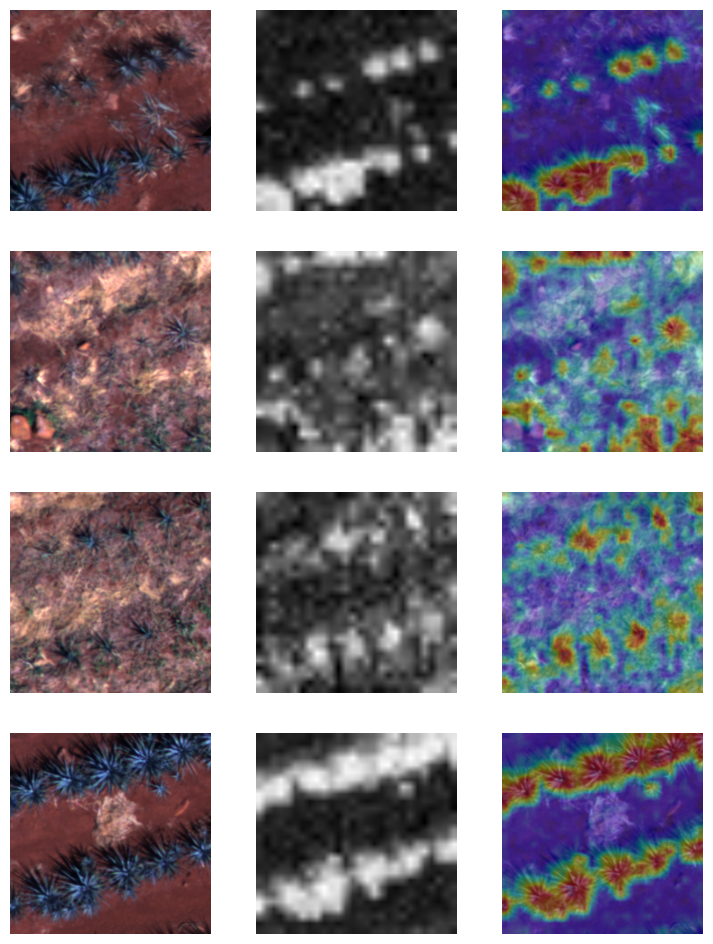

In [23]:
image_paths = [root+"/Datasets Tiles/Zone3/0182_bgr.tif", #3 plants
                root+"/Datasets Tiles/Zone3/0223_bgr.tif",#, #
                root+"/Datasets Tiles/Zone3/0387_bgr.tif", #two plants
                root+"/Datasets Tiles/Zone3/0287_bgr.tif", #5 plants
                root+"/Datasets Tiles/Zone108_octubre/5324_bgr.tif",
                root+"/Datasets Tiles/Zone3/0706_bgr.tif", #5 plants
                root+"/Datasets Tiles/Zone108_octubre/5417_bgr.tif",
               root+"/Datasets Tiles/Zone108_octubre/5282_bgr.tif",
               root+"/Datasets Tiles/Zone108_octubre/5129_bgr.tif"
              ]
image_paths = [#root+"/Datasets Tiles/Zone3/0182.tif", #3 plants
                #root+"/Datasets Tiles/Zone3/0223.tif",#, #
                #root+"/Datasets Tiles/Zone3/0387.tif", #two plants
                #root+"/Datasets Tiles/Zone3/0287.tif", #5 plants
                #root+"/Datasets Tiles/Zone108_octubre/5324.tif",
                #root+"/Datasets Tiles/Zone3/0706.tif", #5 plants
                #root+"/Datasets Tiles/Zone108_octubre/5417.tif",
               #root+"/Datasets Tiles/Zone108_octubre/5282.tif",
               #root+"/Datasets Tiles/Zone108_octubre/5129.tif"
                root+"/Datasets Tiles/Zone102_part1/7429.tif",
               root+"/Datasets Tiles/Zone102_part1/7529.tif",
                root+"/Datasets Tiles/Zone102_part1/7530.tif",
               root+"/Datasets Tiles/Zone102_part1/7412.tif",
              ]

plt.figure(figsize=(9, 3*len(image_paths)))
for i, image_path in enumerate(image_paths):
    image = imread(image_path)
    #image[...,:3] = image[...,:3]/image[...,:3].max()
    image = image[...,:3]
    
    image = preprocess_image(image).to(device).requires_grad_(True)
    image_plot = image[0].permute(1, 2, 0)[:,:,[2, 1, 0]].detach().cpu(); #image_plot = image_plot/image_plot.max()
    
    import model.transformer
    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                         obj = obj, device=device, bitNet=bitNet).to(device)
    
    checkpoint = torch.load(model_dir, map_location=torch.device(device))
    if type(checkpoint) == dict:
        model.load_state_dict(checkpoint['model'])
    else:
        model.load_state_dict( checkpoint )
    boxes, scores, tokens, adjusts, masks  = inference(model, image, obj, conf_thr, diou_thr, device=device)

    import model.transformer
    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                         obj = obj, device=device, bitNet=bitNet).to(device)
    
    checkpoint = torch.load(model_dir, map_location=torch.device(device))
    if type(checkpoint) == dict:
        model.load_state_dict(checkpoint['model'])
    else:
        model.load_state_dict( checkpoint )
        
    arr = tokens[0].reshape(1, -1).detach().cpu().numpy().squeeze()
    toks = arr.tolist() if arr.ndim > 0 else [int(arr)]
    
    image_cpu = image.cpu()
    target_layer=model.encoder1.blks[-1].ln1
    #target_layer = model.encoder1.blks[-1].attention.fc_o
    #target_layer = model.encoder1.ln
    #target_layer = model.encoder1.blks[-1].attention.fc_o
    _,transformer_attribution=ViT_CX(model,image_cpu,target_layer,target_category=toks,distance_threshold=0.1,gpu_batch=8)
    #print("OUTPUT ", transformer_attribution.shape)
    #transformer_attribution = transformer_attribution.sum(0)#[:, 344, :]
    #transformer_attribution = rollout[:, 444, :]

    transformer_attribution = (transformer_attribution - transformer_attribution.min()) / (transformer_attribution.max() - transformer_attribution.min())
    #t1_q1, t1_q99 = np.percentile(transformer_attribution, [3, 95])
    #transformer_attribution = (transformer_attribution-t1_q1)/(t1_q99-t1_q1)
    #transformer_attribution = np.clip(transformer_attribution, 0, 1)
    
    plt.subplot(len(image_paths), 3, 3*i+1)
    plt.imshow(image_plot)
    plt.axis('off')
    plt.subplot(len(image_paths), 3, 3*i+2)
    plt.imshow(transformer_attribution, cmap='gray')
    plt.axis('off')
    plt.subplot(len(image_paths), 3, 3*i+3)  
    plt.imshow(image_plot)
    plt.axis('off')
    plt.imshow(transformer_attribution, cmap='jet', alpha=0.4)

    model.cpu()
    del model#, transformer_attribution
    import gc
    gc.collect()
    torch.cuda.empty_cache()
    
    print(f"Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
    print(f"Reserved: {torch.cuda.memory_reserved()/1024**2:.2f} MB")
#plt.savefig("test1_cx.png", dpi=300)

## Evaluate explainability metrics

In [11]:
import model.trainer as trainer

folder_bboxes = root+'/Datasets_STED/Zones_cbbox_dataset_01/'
#folder_bboxes = '/home/a01328525/Datasets_YOLO/Zones_cbbox_dataset_full_10/'
#folder_cbboxes = '/home/a01328525/Datasets_YOLO/Zones_cbboxes_dataset_03/' 
#folder_bboxes = root+'Datasets_STED/Zones_cbbox_dataset_features_10/'

obj = 'cbbox'
dataloader, test_dataloader = trainer.get_dataloaders(folder_bboxes, obj, augment=True, prob=1, batch_size=1, 
                                                      extract_masks=True, n_channels=3)


Load train data with 3026 images
Load val data with 1377 images


In [12]:
def explain(model_dir, image, tokens):
   
    import model.transformer
    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                         obj = obj, device=device, bitNet=bitNet).to(device)
    checkpoint = torch.load(model_dir, map_location=torch.device(device))
    if type(checkpoint) == dict:
        model.load_state_dict(checkpoint['model'])
    else:
        model.load_state_dict( checkpoint )
                
    image_cpu = image.cpu()
    target_layer=model.encoder1.blks[-1].ln1
    
    if len(tokens)>0:
        _,result = ViT_CX(model,image_cpu,target_layer,target_category=tokens,distance_threshold=0.1,gpu_batch=8)
        #result = result.mean(0)
    else:
        result = torch.zeros(224, 224)
        
    model.cpu()
    del model
    import gc
    gc.collect()
    torch.cuda.empty_cache()
    return result

In [13]:
file_name = 'VIT-CX_Metrics_DA.csv'
try:
    df = pd.read_csv(file_name)
    del_aucs = list(df['Deletion'])
    ins_aucs = list(df['Insertion'])
    poi_gams = list(df['Pointing Game'])
    ene_pois = list(df['Energy Pointing Game'])
    topk_ints = list(df['Top-k Inter'])
    times = list(df['Times'])
except:
    print("No file found!")
    del_aucs = []
    ins_aucs = []
    poi_gams = []
    ene_pois = []
    topk_ints = []
    times = []
print(len(del_aucs))
model_dir = folder_trained_models+"explain_STED_1001_nano_cbbox_bgr_diou_BitNet/best.pt"

100


In [14]:
import model.trainer as trainer

folder_bboxes = root+'/Datasets_STED/Zones_cbbox_dataset_01/'
#folder_bboxes = '/home/a01328525/Datasets_YOLO/Zones_cbbox_dataset_full_10/'
#folder_cbboxes = '/home/a01328525/Datasets_YOLO/Zones_cbboxes_dataset_03/' 
#folder_bboxes = root+'Datasets_STED/Zones_cbbox_dataset_features_10/'

obj = 'cbbox'
dataloader, test_dataloader = trainer.get_dataloaders(folder_bboxes, obj, augment=False, prob=0, batch_size=1, 
                                                      extract_masks=True, n_channels=3)

Load train data with 3026 images
Load val data with 1377 images


In [15]:
it = 0
print(model_dir)
for i in test_dataloader:
    it+=1
    if it <=len(del_aucs):
        continue
    P, imgs, targets, masks =  i
    
    import model.transformer
    model = model.transformer.TransformerObjectDetection(img_size, N_channels, n_model, num_blks, 
                                                         obj = obj, device=device, bitNet=bitNet).to(device)
    checkpoint = torch.load(model_dir, map_location=torch.device(device))
    if type(checkpoint) == dict:
        model.load_state_dict(checkpoint['model'])
    else:
        model.load_state_dict( checkpoint )
    #print("Model loaded")

    imgs = imgs.to(device)
    boxes, scores, tokens, adjusts, _  = inference(model, imgs, obj, conf_thr, diou_thr, device=device)
    ###############################################################

    arr = tokens[0].reshape(1, -1).detach().cpu().numpy().squeeze()
    if arr.ndim > 0:
        toks = arr.tolist() 
    else: 
        toks = [int(arr)]
    
    start = time.perf_counter()
    #results = explain_chefer(model_dir, imgs, toks)
    results = explain(model_dir, imgs, toks)
    end = time.perf_counter()
    
    del_auc = deletion_auc(model, imgs, results, tokens[0], boxes[0], expanded_box=1.4)
    ins_auc = insertion_auc(model, imgs, results, tokens[0], boxes[0], expanded_box=1.4)
    poi_gam = pointing_game_circle(results, boxes[0], masks, expanded_box=1.4)
    ene_poi = energy_pointing(results, masks[0,0,...])
    topk_int = topk_localization(results, boxes[0], masks[0,0,...], expanded_box=1.4)
    
    del_aucs.append(del_auc)
    ins_aucs.append(ins_auc)
    poi_gams.append(poi_gam)
    ene_pois.append(ene_poi)
    topk_ints.append(topk_int)
    times.append(end-start)
    
    print('\r', "Image:%4d"%(it), end='')
    if it==100:
        break
    if it%10==0:
        print()
        print(np.array(del_aucs).mean(), np.array(ins_aucs).mean(), np.array(poi_gams).mean(), np.array(ene_pois).mean(), np.array(times).mean())

        # Create the DataFrame using a dictionary
        df = pd.DataFrame({
            'Deletion': np.array(del_aucs),
            'Insertion': np.array(ins_aucs),
            'Pointing Game': np.array(poi_gams),
            'Energy Pointing Game': np.array(ene_pois),
            'Top-k Inter': np.array(topk_ints),
            'Times': np.array(times)
        })
        df.to_csv(file_name)
    model.cpu()
    del model
    import gc
    gc.collect()
    torch.cuda.empty_cache()
    
del_aucs = np.array(del_aucs)
ins_aucs = np.array(ins_aucs)
poi_gams = np.array(poi_gams)
ene_pois = np.array(ene_pois)
topk_ints = np.array(topk_ints)
times = np.array(times)

print()
print(del_aucs.mean(), ins_aucs.mean(), poi_gams.mean(), ene_pois.mean(), times.mean())

# Create the DataFrame using a dictionary
df = pd.DataFrame({
    'Deletion': del_aucs,
    'Insertion': ins_aucs,
    'Pointing Game': poi_gams,
    'Energy Pointing Game': ene_pois,
    'Top-k Inter': topk_ints,
    'Times': times
})
df.to_csv(file_name)

/home/a01328525/Datasets_STED/runs_transformers/explain_STED_1001_nano_cbbox_bgr_diou_BitNet/best.pt


/home/a01328525/anaconda3/lib/python3.9/site-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


 Image: 110
0.1158271633765914 0.7505120074207132 0.9262194048719522 0.17527528118258495 0.5171824010635068
 Image: 120
0.11805852241814134 0.7448060939709346 0.9220106449421465 0.18056709130838805 0.5151905263497913
 Image: 130
0.11855433829701861 0.7474578761137449 0.9204397252611113 0.17764306716836686 0.5147376319843785
 Image: 140
0.11997358623359884 0.7401253591690745 0.9220017229072958 0.18153025780073484 0.51466453984979
 Image: 150
0.12068845460812248 0.7385864720741908 0.9234053117505131 0.1838829551084661 0.5144895288931487
 Image: 160
0.11955654467456041 0.7395539121702314 0.9179246226232489 0.18017133569578395 0.5128070794185987
 Image: 170
0.11927954344188464 0.742998138420722 0.9179461179565896 0.17606786938494387 0.5130621090116405
 Image: 180
0.12020834891332519 0.7451615676283836 0.9166755423798766 0.17570214356192893 0.5137335741610312
 Image: 190
0.119566092875443 0.7454220268287157 0.9164630869329827 0.1746735996498147 0.5145603715420293
 Image: 200
0.1191520959511

 Image: 870
0.11919475747593518 0.7629370118095272 0.8965871340759245 0.16878048940733117 0.5076771314838388
 Image: 880
0.119164908609607 0.7631623358973725 0.8965298668596937 0.1688596973196743 0.5077894187101637
 Image: 890
0.11913605145691486 0.7633622721423594 0.8969031432094535 0.16863077634516602 0.5078648798066742
 Image: 900
0.11901263338410192 0.7632874196188317 0.8970680641931932 0.16868141757024369 0.5079578792054842
 Image: 910
0.11900745466105886 0.7632953966793778 0.8967410271395064 0.1686551906323011 0.5077830534274084
 Image: 920
0.11897327140702502 0.7632129934251957 0.8973975687699776 0.1682162768805776 0.507857795695572
 Image: 930
0.11912883407566496 0.7623735979119296 0.8973359461667162 0.16892270654029462 0.5076646483827219
 Image: 940
0.11928456080482995 0.7610997427730484 0.8979721899005049 0.16969793786780354 0.5078288571818469
 Image: 950
0.1192102286964655 0.7602947294790494 0.8977303773752364 0.16985340741031774 0.5076628451894066
 Image: 960
0.119162459869

In [27]:
file_name = 'Rollout_Metrics_no_DA.csv'
df1 = pd.read_csv(file_name, index_col=0)
file_name = 'Rollout_Metrics_DA.csv'
df2 = pd.read_csv(file_name, index_col=0)

file_name = 'Chefer_Metrics_no_DA.csv'
df3 = pd.read_csv(file_name, index_col=0)
file_name = 'Chefer_Metrics_DA.csv'
df4 = pd.read_csv(file_name, index_col=0)

file_name = 'VIT-CX_Metrics_no_DA.csv'
df5 = pd.read_csv(file_name, index_col=0)
file_name = 'VIT-CX_Metrics_DA.csv'
df6 = pd.read_csv(file_name, index_col=0)

In [28]:
dfs = [df1, df2, df3, df4, df5, df6]

In [29]:
for i in range(len(dfs)):
    print(len(dfs[i]))

1377
1377
1377
1377
1377
1377


In [30]:
for i in range(len(dfs)):
    means_1 = []
    stds_1 = []

    for col_s in dfs[i].columns:
        accs = np.array(dfs[i][col_s])
        
        means_1.append(accs.mean())
        stds_1.append(accs.std())
    print("& %4.2f \small{±~%.2f} & %4.2f \small{±~%.2f} & %4.2f \small{±~%.2f} & %4.2f \small{±~%.2f} \\\\" %(means_1[0], stds_1[0], means_1[1], stds_1[1], means_1[2], stds_1[2], means_1[4], stds_1[4]))

dfs[0].columns[[0, 1, 2, 4]]

& 0.27 \small{±~0.13} & 0.71 \small{±~0.12} & 0.78 \small{±~0.25} & 0.75 \small{±~0.23} \\
& 0.22 \small{±~0.11} & 0.72 \small{±~0.13} & 0.81 \small{±~0.24} & 0.80 \small{±~0.22} \\
& 0.26 \small{±~0.14} & 0.71 \small{±~0.11} & 0.73 \small{±~0.27} & 0.71 \small{±~0.26} \\
& 0.23 \small{±~0.11} & 0.71 \small{±~0.12} & 0.79 \small{±~0.26} & 0.78 \small{±~0.24} \\
& 0.19 \small{±~0.15} & 0.73 \small{±~0.15} & 0.79 \small{±~0.30} & 0.78 \small{±~0.28} \\
& 0.12 \small{±~0.05} & 0.76 \small{±~0.13} & 0.90 \small{±~0.22} & 0.89 \small{±~0.20} \\


Index(['Deletion', 'Insertion', 'Pointing Game', 'Top-k Inter'], dtype='object')

In [31]:
dfs[i].columns

Index(['Deletion', 'Insertion', 'Pointing Game', 'Energy Pointing Game',
       'Top-k Inter', 'Times'],
      dtype='object')

In [39]:
from scipy.stats import ttest_rel  # Paired t-test

means_1 = []
means_2 = []
stds_1 = []
stds_2 = []

for col_s in dfs[0].columns:
    noDA_accuracies = np.array(df2[col_s])
    DA_accuracies = np.array(df6[col_s])
    
    print(f"No DA Accuracy: {noDA_accuracies.mean():.3f} ± {noDA_accuracies.std():.3f}")
    print(f"DA Accuracy: {DA_accuracies.mean():.3f} ± {DA_accuracies.std():.3f}")
    t_stat, p_value = ttest_rel(noDA_accuracies, DA_accuracies)
    if p_value<0.05:
        print(f"SIGNIFICANT p-value: {p_value:.4f} for {col_s}")  # p < 0.05 → statistically significant
    else:
        print(f"*********NOT SIGNIFICANT p-value: {p_value:.4f} for {col_s}")  # p < 0.05 → statistically significant
    means_1.append(noDA_accuracies.mean())
    means_2.append(DA_accuracies.mean())
    stds_1.append(noDA_accuracies.std())
    stds_2.append(DA_accuracies.std())
    
print("%6.2f ± %.2f & %4.2f ± %.2f & %4.2f ± %.2f \\\\" %(means_1[0], stds_1[0], means_1[1], stds_1[1], means_1[2], stds_1[2] ) )
print("%6.2f ± %.2f & %4.2f ± %.2f & %4.2f ± %.2f \\\\" %(means_2[0], stds_2[0], means_2[1], stds_2[1], means_2[2], stds_2[2] ) )

No DA Accuracy: 0.219 ± 0.111
DA Accuracy: 0.119 ± 0.051
SIGNIFICANT p-value: 0.0000 for Deletion
No DA Accuracy: 0.719 ± 0.125
DA Accuracy: 0.759 ± 0.131
SIGNIFICANT p-value: 0.0000 for Insertion
No DA Accuracy: 0.814 ± 0.239
DA Accuracy: 0.897 ± 0.218
SIGNIFICANT p-value: 0.0000 for Pointing Game
No DA Accuracy: 0.154 ± 0.101
DA Accuracy: 0.171 ± 0.114
SIGNIFICANT p-value: 0.0000 for Energy Pointing Game
No DA Accuracy: 0.798 ± 0.219
DA Accuracy: 0.893 ± 0.203
SIGNIFICANT p-value: 0.0000 for Top-k Inter
No DA Accuracy: 0.375 ± 0.059
DA Accuracy: 0.510 ± 0.064
SIGNIFICANT p-value: 0.0000 for Times
  0.22 ± 0.11 & 0.72 ± 0.13 & 0.81 ± 0.24 \\
  0.12 ± 0.05 & 0.76 ± 0.13 & 0.90 ± 0.22 \\
